## Bank Marketing
A base utilizada contém informações de clientes de uma instituição bancária e o resultado de campanhas de marketing direto realizadas para oferta de produtos financeiros.
Ela é baseada em dados reais de uma campanha de marketing bancário, mas com algumas características importantes sobre privacidade e anonimização.

Ela foi criada a partir de campanhas de marketing direto de uma instituição bancária portuguesa, coletadas entre maio de 2008 e novembro de 2010. O objetivo era prever se um cliente aceitaria uma oferta de depósito a prazo (term deposit) após ser contatado por telefone.

O objetivo original da campanha era prever se um cliente aceitaria ou não uma oferta de depósito a prazo após ser contatado pelo banco.

| y   | Significado                        |
| --- | ---------------------------------- |
| yes | cliente aceitou o depósito a prazo |
| no  | cliente recusou                    |


### 1. Download dos dados

In [1]:
'''
from pathlib import Path
import shutil
import kagglehub

# Faz o download da base
download_path = kagglehub.dataset_download("henriqueyamahata/bank-marketing")
download_path = Path(download_path)
destino = Path("../data/raw")  # ajuste conforme a localização do notebook

destino.mkdir(parents=True, exist_ok=True)

for arquivo in download_path.iterdir():
    if arquivo.is_file():
        shutil.copy2(arquivo, destino / arquivo.name)

print("Arquivos copiados com sucesso!")
'''

'\nfrom pathlib import Path\nimport shutil\nimport kagglehub\n\n# Faz o download da base\ndownload_path = kagglehub.dataset_download("henriqueyamahata/bank-marketing")\ndownload_path = Path(download_path)\ndestino = Path("../data/raw")  # ajuste conforme a localização do notebook\n\ndestino.mkdir(parents=True, exist_ok=True)\n\nfor arquivo in download_path.iterdir():\n    if arquivo.is_file():\n        shutil.copy2(arquivo, destino / arquivo.name)\n\nprint("Arquivos copiados com sucesso!")\n'

### 2. Leitura dos dados

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys

# Configura caminho para a raiz do projeto (tech_challenge_5)
PROJECT_ROOT = Path.cwd().parent

# Adiciona a raiz do projeto ao caminho de busca do Python,
# permitindo importar módulos da pasta src.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Agora o import funciona
from src.config import RAW_DATA_PATH

df = pd.read_csv(
    RAW_DATA_PATH / "bank-additional-full.csv",
    sep=";"
)

pd.set_option("display.max_columns", None) #visualizar todas as colunas
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
print(f"A base possui {df.shape[0]} linhas e {df.shape[1]} colunas.")

A base possui 41188 linhas e 21 colunas.


### 3. Remoção de colunas data leakage

A variável *duration* será removida durante a preparação dos dados devido ao risco de data leakage.

Essa variável representa a duração do contato realizado com o cliente e somente estaria disponível após o início da interação. Como o objetivo do sistema é recomendar a melhor oferta antes do contato, utilizar essa informação criaria uma situação irreal, causando uma superestimação do desempenho do modelo.

As demais variáveis foram mantidas por estarem disponíveis no momento da decisão.

In [4]:
columns_to_remove = [
    "duration"
]

df = df.drop(columns=columns_to_remove)

#### 4. Entendimento dos dados

Não há dados nulos na base, os dados desconhecidos estão populados como "Unknown".

In [5]:
# Descrição de todas as colunas
df.describe(include="all")

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41188.00000,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188.000000,41188.000000,41188.000000,41188,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188
unique,NaN,12,4,8,3,3,3,2,10,5,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,2
top,NaN,admin.,married,university.degree,no,yes,no,cellular,may,thu,NaN,NaN,NaN,nonexistent,NaN,NaN,NaN,NaN,NaN,no
freq,NaN,10422,24928,12168,32588,21576,33950,26144,13769,8623,NaN,NaN,NaN,35563,NaN,NaN,NaN,NaN,NaN,36548
mean,40.02406,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.567593,962.475454,0.172963,NaN,0.081886,93.575664,-40.502600,3.621291,5167.035911,NaN
std,10.42125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.770014,186.910907,0.494901,NaN,1.570960,0.578840,4.628198,1.734447,72.251528,NaN
min,17.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,NaN,-3.400000,92.201000,-50.800000,0.634000,4963.600000,NaN
25%,32.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,999.000000,0.000000,NaN,-1.800000,93.075000,-42.700000,1.344000,5099.100000,NaN
50%,38.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,999.000000,0.000000,NaN,1.100000,93.749000,-41.800000,4.857000,5191.000000,NaN
75%,47.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,999.000000,0.000000,NaN,1.400000,93.994000,-36.400000,4.961000,5228.100000,NaN


**Valores possíveis para cada variável**
* age: 17-98
* job: admin, blue, technician, services, management, retired, entrepreneur, self, housemaid, unemployed, student, unknown
* marital: married, single, divorced, unknown
* education: university.degree, high.school, basic.9y, professional.course, basic.4y, basic.6y, unknown, illiterate
* default: no, unknown, yes
* housing: no, unknown, yes
* loan: no, unknown, yes
* contact: cellular, telephone
* month: march-december
* day_of_week: monday-friday
* campaing: 1-56
* pdays: 0-999
* previous: 0-7
* poutcome: nonexistent, failure, success
* emp.var.rate: [-3.4, 1.4]
* cons.price.idx: [92.201, 94.767]
* cons.conf.idx: [-50.8, -26,9]
* euribor3m: [0.634, 5.045]
* nr.employed: [4963.6, 5228.1]
* y: yes, no


In [6]:
# Colunas disponíveis e respectivos formatos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null 

Valores preenchidos como "unknown"

In [7]:
unknown_summary = (
    (df == "unknown")
    .sum()
    .to_frame(name="Quantidade")
)

unknown_summary["Percentual (%)"] = (
    unknown_summary["Quantidade"] / len(df) * 100
).round(2)

unknown_summary = unknown_summary[
    unknown_summary["Quantidade"] > 0
].sort_values(
    by="Quantidade",
    ascending=False
)

unknown_summary

,Quantidade,Percentual (%)
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


### 5. Comportamento do target

Criar versão numérica do target

In [8]:
df["y_num"] = df["y"].map({
    "no": 0,
    "yes": 1
})

Visualizar balanceamento do target: há prevalência de não conversão 

In [9]:
print(f"Há {(df['y'] == 'no').sum()} registros sem conversão e {(df['y'] == 'yes').sum()} convertidos.")
print(f"Há {((df['y'] == 'no').sum() / len(df)) * 100:.2f}% registros sem conversão e {((df['y'] == 'yes').sum() / len(df)) * 100:.2f}% convertidos.")

Há 36548 registros sem conversão e 4640 convertidos.
Há 88.73% registros sem conversão e 11.27% convertidos.


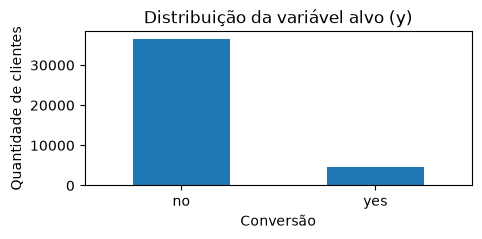

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,2))

df["y"].value_counts().plot(
    kind="bar"
)

plt.title("Distribuição da variável alvo (y)")
plt.xlabel("Conversão")
plt.ylabel("Quantidade de clientes")

plt.xticks(rotation=0)

plt.show()

Conversão por mês

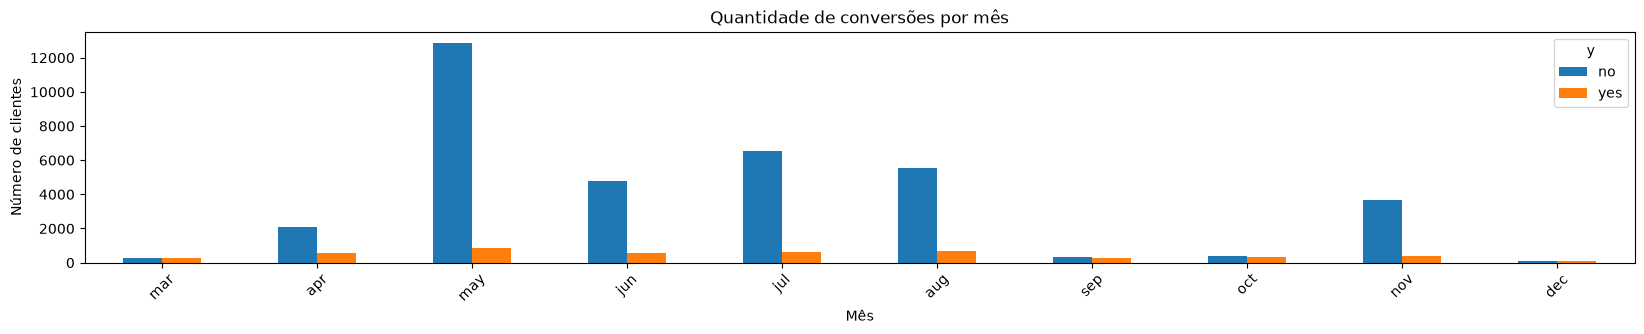

In [11]:
month_order = [
    "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct",
    "nov", "dec"
]

y_month = (
    df.groupby(["month", "y"])
      .size()
      .unstack()
      .reindex(month_order)
)

y_month.plot(
    kind="bar",
    figsize=(20,3)
)

plt.title("Quantidade de conversões por mês")
plt.xlabel("Mês")
plt.ylabel("Número de clientes")
plt.xticks(rotation=45)

plt.show()

### 6. Correlação entre features e target

One-hot-encoding

In [12]:
X = df.drop(columns=["y"])
y = df["y"]

In [13]:
categorical_features = X.select_dtypes(include="object").columns.tolist()
categorical_features

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome']

In [14]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

X_encoded = encoder.fit_transform(
    X[categorical_features]
)

In [15]:
encoded_columns = encoder.get_feature_names_out(categorical_features)

In [16]:
import pandas as pd

X_encoded = pd.DataFrame(
    X_encoded,
    columns=encoded_columns,
    index=X.index
)

In [17]:
X_numeric = X.drop(columns=categorical_features)

X_final = pd.concat(
    [X_numeric, X_encoded],
    axis=1
)

X_final.head()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y_num,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,marital_unknown,education_basic.4y,education_basic.6y,education_basic.9y,education_high.school,education_illiterate,education_professional.course,education_university.degree,education_unknown,default_no,default_unknown,default_yes,housing_no,housing_unknown,housing_yes,loan_no,loan_unknown,loan_yes,contact_cellular,contact_telephone,month_apr,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,57,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,37,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,40,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


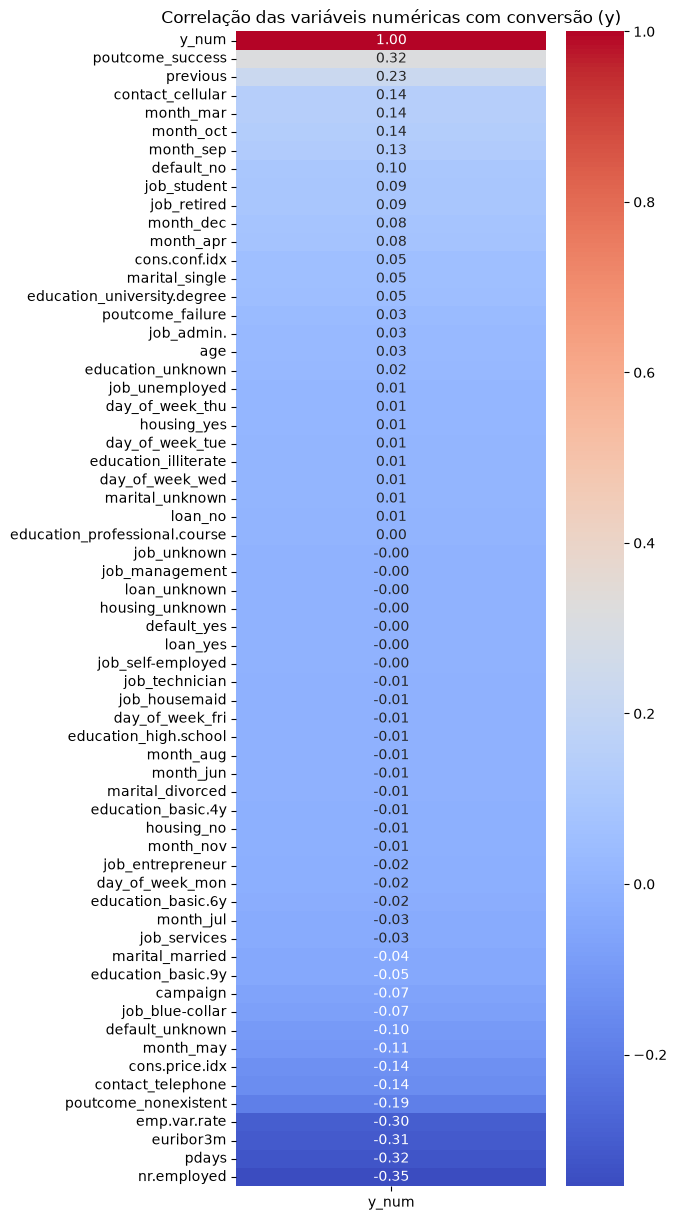

In [18]:
import seaborn as sns

numeric_cols = X_final.select_dtypes(
    include="number"
).columns

corr = (
    X_final[numeric_cols]
    .corr()
)

plt.figure(figsize=(5,15))

sns.heatmap(
    corr[["y_num"]]
    .sort_values(
        by="y_num",
        ascending=False
    ),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlação das variáveis numéricas com conversão (y)")
plt.show()

In [19]:
X_final.groupby("y_num")[
    ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
].mean().T

y_num,0,1
age,39.911185,40.913147
campaign,2.633085,2.051724
pdays,984.113878,792.035560
previous,0.132374,0.492672
emp.var.rate,0.248875,-1.233448
cons.price.idx,93.603757,93.354386
cons.conf.idx,-40.593097,-39.789784
euribor3m,3.811491,2.123135
nr.employed,5176.166600,5095.115991


In [20]:
X_final.groupby("y_num")[
    ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
].median().T

y_num,0,1
age,38.000,37.000
campaign,2.000,2.000
pdays,999.000,999.000
previous,0.000,0.000
emp.var.rate,1.100,-1.800
cons.price.idx,93.918,93.200
cons.conf.idx,-41.800,-40.400
euribor3m,4.857,1.266
nr.employed,5195.800,5099.100


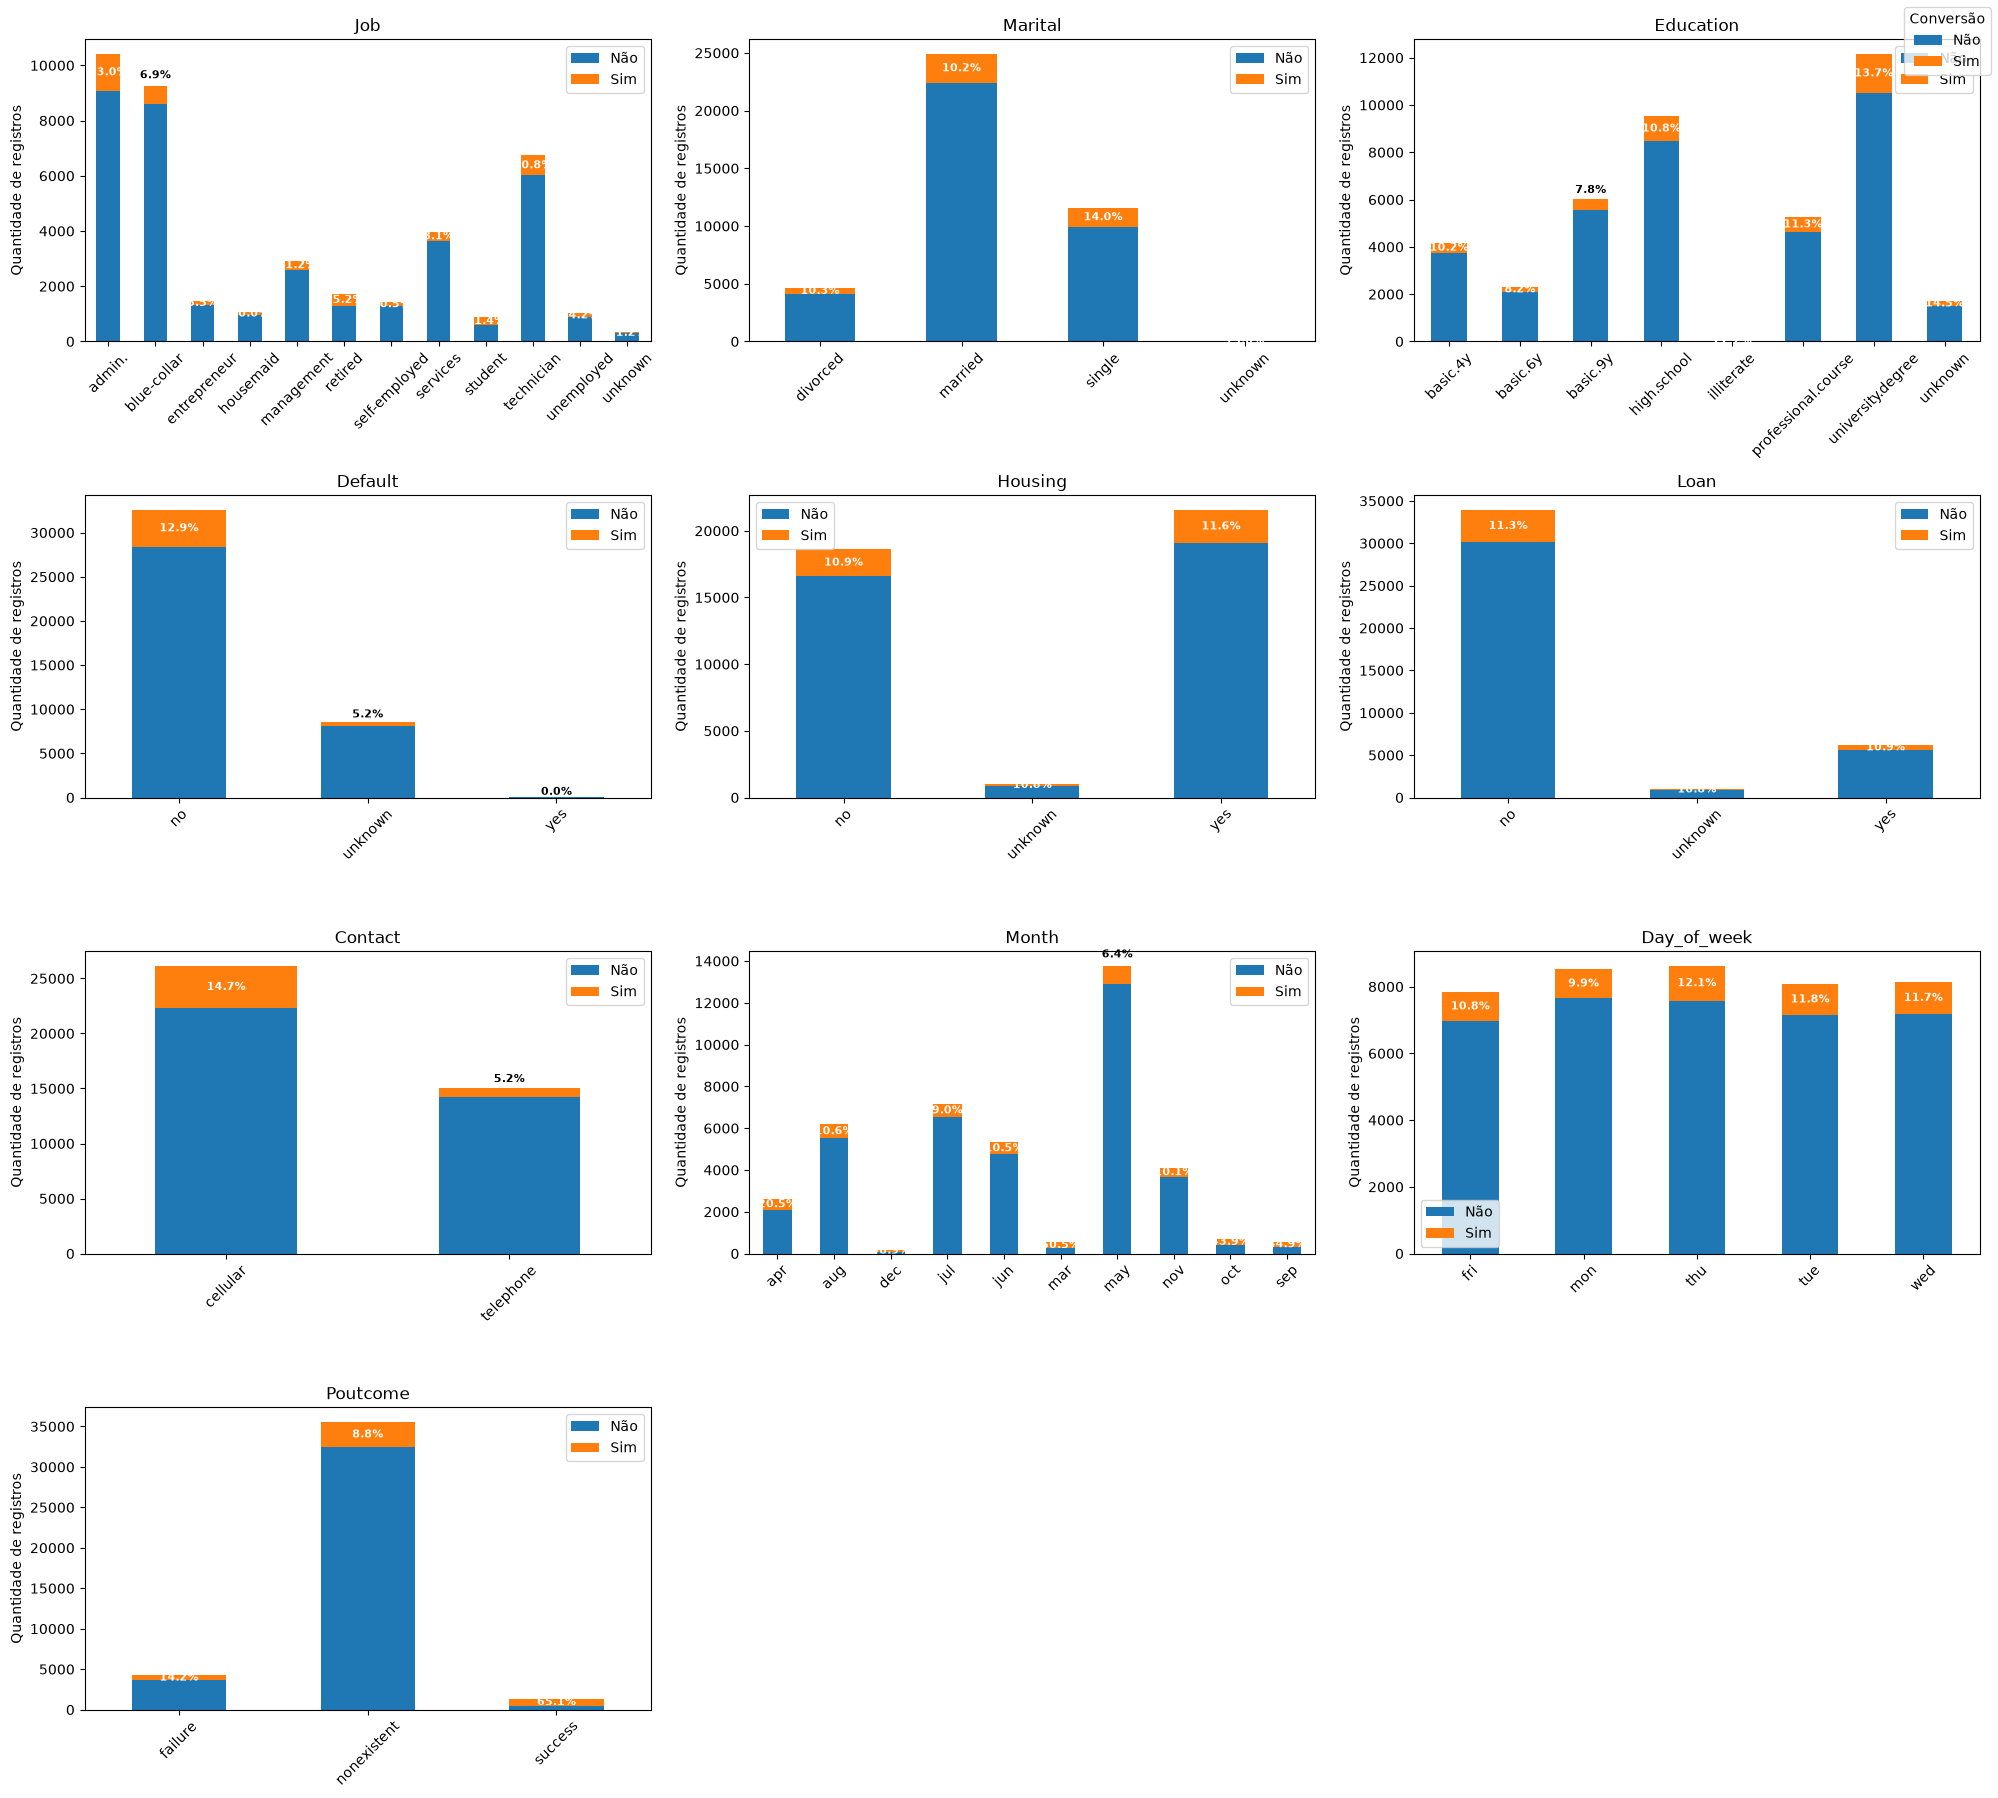

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

categorias = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "day_of_week",
    "poutcome"
]

fig, axes = plt.subplots(
    4,
    3,
    figsize=(20, 18)
)

axes = axes.flatten()

for i, categoria in enumerate(categorias):

    # Seleciona as colunas One-Hot da categoria
    cols = [
        col
        for col in X_final.columns
        if col.startswith(f"{categoria}_")
    ]

    # Conta registros por classe
    counts = pd.DataFrame(index=cols)

    counts["Não"] = [
        X_final.loc[
            (X_final[col] == 1) &
            (X_final["y_num"] == 0)
        ].shape[0]
        for col in cols
    ]

    counts["Sim"] = [
        X_final.loc[
            (X_final[col] == 1) &
            (X_final["y_num"] == 1)
        ].shape[0]
        for col in cols
    ]

    # Remove o prefixo do nome da categoria
    counts.index = counts.index.str.replace(
        f"{categoria}_",
        "",
        regex=False
    )

    # Plota barras empilhadas
    counts.plot(
        kind="bar",
        stacked=True,
        ax=axes[i]
    )

    # Adiciona percentual de conversão em cada barra
    for j, (_, row) in enumerate(counts.iterrows()):

        total = row["Não"] + row["Sim"]

        if total == 0:
            continue

        taxa = row["Sim"] / total * 100

        # Se houver espaço suficiente, escreve dentro da parte "Sim".
        # Caso contrário, escreve acima da barra.
        if row["Sim"] >= total * 0.08:
            y = row["Não"] + row["Sim"] / 2
            color = "white"
            va = "center"
        else:
            y = total + total * 0.02
            color = "black"
            va = "bottom"

        axes[i].text(
            x=j,
            y=y,
            s=f"{taxa:.1f}%",
            ha="center",
            va=va,
            fontsize=8,
            fontweight="bold",
            color=color
        )

    axes[i].set_title(categoria.capitalize())
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Quantidade de registros")
    axes[i].tick_params(axis="x", rotation=45)

# Remove os eixos vazios
for j in range(len(categorias), len(axes)):
    fig.delaxes(axes[j])

# Legenda única
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Conversão",
    loc="upper right"
)

plt.tight_layout()
plt.show()

### 7. Entender o momento econômico da época com base nos índices econômicos

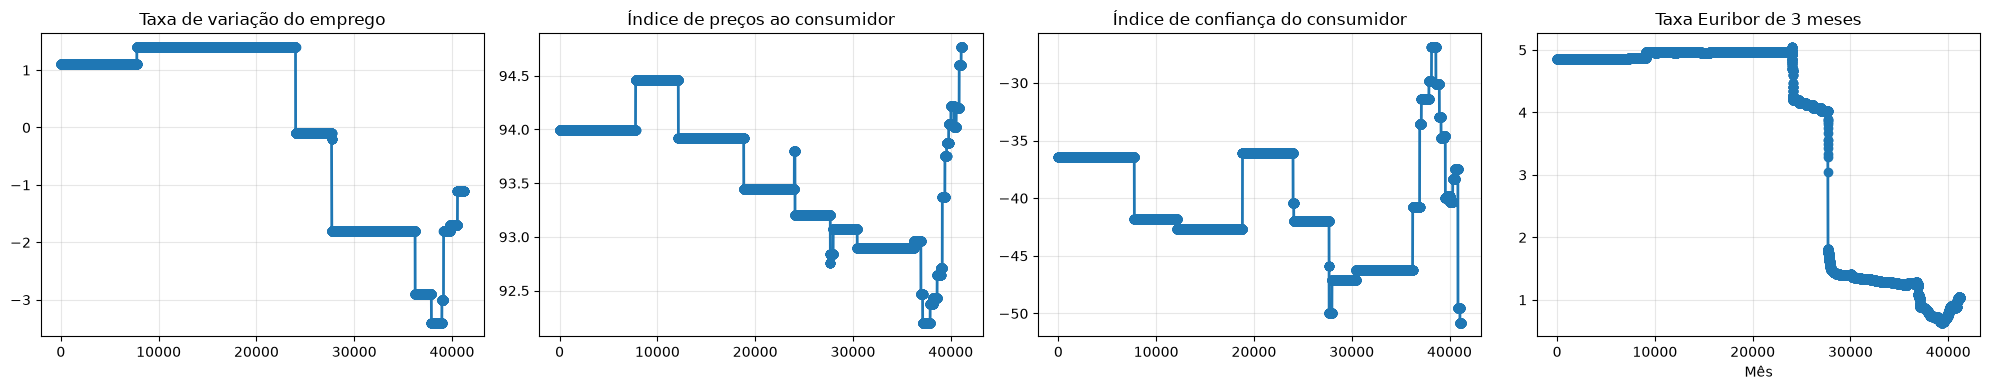

In [24]:
df_market = df.copy()

fig, axes = plt.subplots(
    1,
    4,
    figsize=(20, 4),
    sharex=True
)

# emp.var.rate
axes[0].plot(
    df_market.index,
    df_market["emp.var.rate"],
    marker="o",
    linewidth=2
)
axes[0].set_title("Taxa de variação do emprego")
axes[0].grid(alpha=0.3)

# cons.price.idx
axes[1].plot(
    df_market.index,
    df_market["cons.price.idx"],
    marker="o",
    linewidth=2
)
axes[1].set_title("Índice de preços ao consumidor")
axes[1].grid(alpha=0.3)

# cons.conf.idx
axes[2].plot(
    df_market.index,
    df_market["cons.conf.idx"],
    marker="o",
    linewidth=2
)
axes[2].set_title("Índice de confiança do consumidor")
axes[2].grid(alpha=0.3)

# euribor3m
axes[3].plot(
    df_market.index,
    df_market["euribor3m"],
    marker="o",
    linewidth=2
)
axes[3].set_title("Taxa Euribor de 3 meses")
axes[3].set_xlabel("Mês")
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()